# Capstone Project
## Image classifier for the SVHN dataset

In this notebook, a neural network was implemented to classifies real-world images digits. This project utilized the conventional techniques employed in deep learning which are building, training, testing, validating and saving the Tensorflow classifier model, an end-to-end workflow that classifies a real-world image into a class.

Also, this project implemented a neural network using Multilayer Perceptron and Convolutional Network as a way to compare and contrast  the performance of these models when it involves applying them for image classification task.

The [SVHN dataset](http://ufldl.stanford.edu/housenumbers/) was used for this image classification task. This is an  image dataset of over 600,000 digit images in all and is a harder dataset than MNIST as the numbers appear in the context of natural scene images. SVHN is obtained from house numbers in Google Street View images and each image in the dataset is assigned to one of the ten classes which are 0, 1, 2, 3, 4, 5, 6, 7, 8, 9. 

* Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu and A. Y. Ng. "Reading Digits in Natural Images with Unsupervised Feature Learning". NIPS Workshop on Deep Learning and Unsupervised Feature Learning, 2011.

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

%matplotlib inline

Both `train` and `test` are dictionaries with keys `X` and `y` for the input images and labels respectively.

In [2]:
# Run this cell to load the dataset

train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')

## Inspect and preprocess the dataset
* Extract the train and test images and labels separately from the loaded train and test dictionaries respectively.
* Select a random sample of images and corresponding labels from the dataset (at least 10), and display them in a figure.
* Convert the train and test images to grayscale by taking the average across all colour channels for each pixel.
* Select a random sample of the grayscale images and corresponding labels from the dataset (at least 10) and display them in a figure.

In [3]:
train_images = train["X"]
train_labels = train["y"]
test_images = test["X"]
test_labels = test["y"]

In [4]:
print("shape of the train images", train_images.shape)
print("shape of the test images", test_images.shape)

shape of the train images (32, 32, 3, 73257)
shape of the test images (32, 32, 3, 26032)


In [5]:
def display_images(digit):
    digit_labels = train_labels[train_labels == digit]
    if len(digit_labels) != 0:
        digit_labels_idxs = np.where(np.isin(train_labels, digit_labels))[0]
        random_digit_images_idxs = np.random.choice(digit_labels_idxs, size=15, replace=False)
        figure, axs = plt.subplots(3, 5)
        
        for idx, ax in zip(random_digit_images_idxs, axs.flat):
            ax.imshow(train_images[:, :, :, idx])
            ax.set_title(train_labels[idx])
            ax.axis("off")
            
        figure.tight_layout()
    
    else:
        return f"{digit} not in the labels"

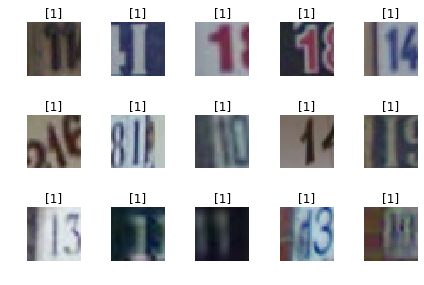

In [6]:
display_images(1)

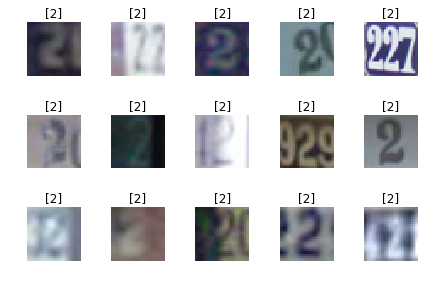

In [7]:
display_images(2)

In [8]:
display_images(0)

'0 not in the labels'

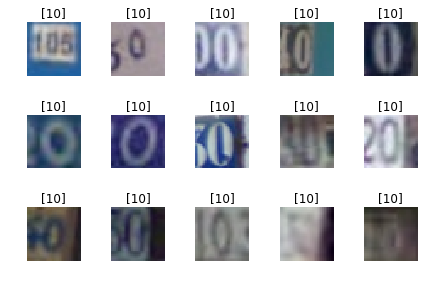

In [9]:
display_images(10)

In [10]:
train_labels = np.where(train_labels == 10, 0, train_labels)
test_labels = np.where(test_labels == 10, 0, test_labels)

In [11]:
display_images(10)

'10 not in the labels'

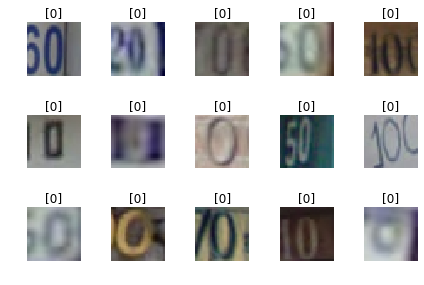

In [12]:
display_images(0)

In [13]:
distinct_labels = np.unique(train_labels)
distinct_labels

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

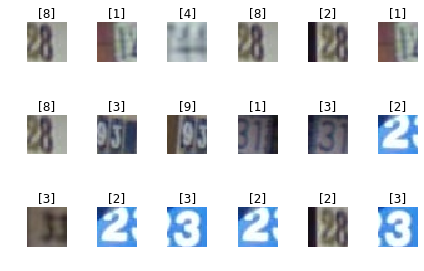

In [14]:
random_imgs = np.random.choice(18, train_images.shape[-1])
fig, ax1 = plt.subplots(3, 6)
for idx, ax in zip(random_imgs, ax1.flat):
    img = train_images[:, :, :, idx]
    label = train_labels[idx]
    ax.imshow(img)
    ax.set_title(label)
    ax.axis('off')

fig.tight_layout()

In [15]:
train_images_gray = train_images.mean(axis=2, keepdims=True)
test_images_gray = test_images.mean(axis=2, keepdims=True)

In [16]:
print("shape of the grayscale train images", train_images_gray.shape)
print("shape of the grayscale test images", test_images_gray.shape)

shape of the grayscale train images (32, 32, 1, 73257)
shape of the grayscale test images (32, 32, 1, 26032)


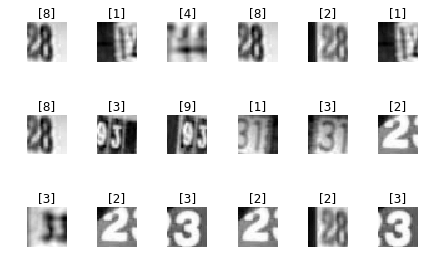

In [17]:
fig2, ax2 = plt.subplots(3, 6)
for idx, ax in zip(random_imgs, ax2.flat):
    img = train_images_gray[:, :, :, idx].reshape(32, 32)
    label = train_labels[idx]
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis('off')

fig2.tight_layout()

## MLP neural network classifier
* Build an MLP classifier model using the Sequential API. The model use only Flatten and Dense layers, with the final layer having a 10-way softmax output.
* Print out the model summary (using the summary() method)
* Compile and train the model over a maximum of 30 epochs, making use of both train and validation sets during the training. 
* The model track at least one appropriate metric and use at least two callbacks during training, one of which was a ModelCheckpoint callback.
* Achieve a final categorical cross entropy training loss of less than 1.0 (the validation loss might be higher).
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both train and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [18]:
train_images_transpose = train_images_gray.transpose(3, 0, 1, 2)
test_images_transpose = test_images_gray.transpose(3, 0, 1, 2)

In [19]:
from tensorflow.keras.utils import to_categorical

In [20]:
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)

In [21]:
def create_mlp():
    mlp = keras.models.Sequential(
        [keras.layers.Flatten(input_shape=(32, 32, 1)),
         
         keras.layers.Dense(250, activation="relu"),
         
         keras.layers.Dense(150, activation="relu"),
         
         keras.layers.Dense(100, activation="relu"),
         
         keras.layers.Dense(10, activation="softmax")
        ]
    )
    
    mlp.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return mlp

In [22]:
mlp = create_mlp()
mlp.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 250)               256250    
_________________________________________________________________
dense_1 (Dense)              (None, 150)               37650     
_________________________________________________________________
dense_2 (Dense)              (None, 100)               15100     
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1010      
Total params: 310,010
Trainable params: 310,010
Non-trainable params: 0
_________________________________________________________________


In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [24]:
def model_checkpoint(dir_path):
    model_checkpoint = ModelCheckpoint(dir_path,
                                       save_weights_only=True,
                                       save_best_only=True,
                                       monitor="loss",
                                       verbose=1
                                      )
    return model_checkpoint

def early_stopping():
    earlystop_check = EarlyStopping(monitor="loss", patience=3, verbose=1)
    return earlystop_check

In [25]:
mlp_dir_path = "checkpoint_mlp"
model_checkpoint_mlp = model_checkpoint(mlp_dir_path+"/best_mlp")
early_stopping_mlp = early_stopping()

In [26]:
mlp_history = mlp.fit(train_images_transpose,
                      encoded_train_labels,
                      validation_data=(test_images_transpose, encoded_test_labels),
                      callbacks=[model_checkpoint_mlp, early_stopping_mlp],
                      epochs=30,
                      verbose=1
                     )

Train on 73257 samples, validate on 26032 samples
Epoch 1/30
73216/73257 [============================>.] - ETA: 0s - loss: 4.1565 - accuracy: 0.2891
Epoch 00001: loss improved from inf to 4.15489, saving model to checkpoint_mlp/best_mlp
73257/73257 [==============================] - 67s 915us/sample - loss: 4.1549 - accuracy: 0.2893 - val_loss: 1.6869 - val_accuracy: 0.4654
Epoch 2/30
73184/73257 [============================>.] - ETA: 0s - loss: 1.5235 - accuracy: 0.5105
Epoch 00002: loss improved from 4.15489 to 1.52306, saving model to checkpoint_mlp/best_mlp
73257/73257 [==============================] - 65s 881us/sample - loss: 1.5231 - accuracy: 0.5106 - val_loss: 1.5155 - val_accuracy: 0.5228
Epoch 3/30
73184/73257 [============================>.] - ETA: 0s - loss: 1.3615 - accuracy: 0.5664
Epoch 00003: loss improved from 1.52306 to 1.36134, saving model to checkpoint_mlp/best_mlp
73257/73257 [==============================] - 64s 880us/sample - loss: 1.3613 - accuracy: 0.5665 

In [27]:
train_loss = mlp_history.history["loss"]
train_acc = mlp_history.history["accuracy"]
val_loss = mlp_history.history["val_loss"]
val_acc = mlp_history.history["val_accuracy"]

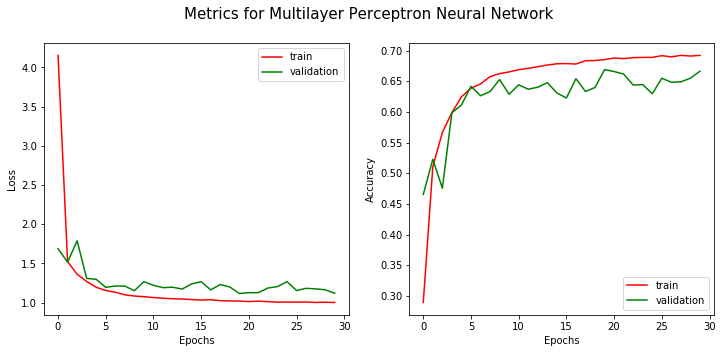

In [28]:
fig, (loss_ax, acc_ax) = plt.subplots(1, 2, figsize=[12, 5])
loss_ax.plot(train_loss, label="train", color="red")
loss_ax.plot(val_loss, label="validation", color="green")
loss_ax.set(xlabel="Epochs", ylabel="Loss")
loss_ax.legend()

acc_ax.plot(train_acc, label="train", color="red")
acc_ax.plot(val_acc, label="validation", color="green")
acc_ax.set(xlabel="Epochs", ylabel="Accuracy")
acc_ax.legend()

fig.suptitle("Metrics for Multilayer Perceptron Neural Network", fontsize=15);

In [29]:
mlp_loss, mlp_acc = mlp.evaluate(test_images_transpose, encoded_test_labels, verbose=0)
print(f"The MLP NN had a loss {mlp_loss:.4f} with {mlp_acc:%} accuracy")

The MLP NN had a loss 1.1184 with 66.641057% accuracy


## CNN neural network classifier
* Build a Convolutional Neural Network (CNN) classifier model using the Sequential API. The model uses the Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense and Dropout layers. The final layer again have a 10-way softmax output.
* The CNN model have fewer trainable parameters than the MLP model.
* Compile and train the model through 30 epochs, making use of both train and validation sets during the training run.
* The CNN model track at least one appropriate metric and use at least two callbacks during training, one of which should be a ModelCheckpoint callback.
* Aim to beat the MLP model performance with fewer parameters!
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both training and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [30]:
def create_convolutional_model():
    conv_model = keras.models.Sequential(
        [keras.layers.Input((32, 32, 1)),
         
         keras.layers.BatchNormalization(),
         keras.layers.Conv2D(16, (4, 4), activation="relu", padding="same"),
         keras.layers.MaxPooling2D(2, 2),
         
         keras.layers.BatchNormalization(),
         keras.layers.Conv2D(8, (4, 4), activation="relu", padding="same"),
         keras.layers.MaxPooling2D(2, 2),
         
         keras.layers.Flatten(),
         
         keras.layers.Dense(16, activation="relu"),
         keras.layers.Dense(10, activation="softmax")
        ]
    )
    
    conv_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return conv_model

In [31]:
conv_model = create_convolutional_model()
conv_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization (BatchNo (None, 32, 32, 1)         4         
_________________________________________________________________
conv2d (Conv2D)              (None, 32, 32, 16)        272       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 16, 16, 16)        0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 16, 16, 16)        64        
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 16, 16, 8)         2056      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 8, 8, 8)           0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 512)              

In [32]:
cnn_dir_path = "checkpoint_cnn"
model_checkpoint_conv = model_checkpoint(cnn_dir_path+"/best_cnn")
early_stopping_conv = early_stopping()

In [33]:
conv_history = conv_model.fit(train_images_transpose,
                              encoded_train_labels,
                              validation_data=(test_images_transpose, encoded_test_labels),
                              callbacks=[model_checkpoint_conv, early_stopping_conv],
                              epochs=30,
                              verbose=1
                             )

Train on 73257 samples, validate on 26032 samples
Epoch 1/30
73248/73257 [============================>.] - ETA: 0s - loss: 0.9989 - accuracy: 0.6783
Epoch 00001: loss improved from inf to 0.99890, saving model to checkpoint_cnn/best_cnn
73257/73257 [==============================] - 409s 6ms/sample - loss: 0.9989 - accuracy: 0.6783 - val_loss: 0.6915 - val_accuracy: 0.7989
Epoch 2/30
73248/73257 [============================>.] - ETA: 0s - loss: 0.5839 - accuracy: 0.8278
Epoch 00002: loss improved from 0.99890 to 0.58403, saving model to checkpoint_cnn/best_cnn
73257/73257 [==============================] - 405s 6ms/sample - loss: 0.5840 - accuracy: 0.8278 - val_loss: 0.6034 - val_accuracy: 0.8234
Epoch 3/30
73248/73257 [============================>.] - ETA: 0s - loss: 0.5244 - accuracy: 0.8468
Epoch 00003: loss improved from 0.58403 to 0.52441, saving model to checkpoint_cnn/best_cnn
73257/73257 [==============================] - 402s 5ms/sample - loss: 0.5244 - accuracy: 0.8468 - v

In [34]:
cnn_train_loss = conv_history.history["loss"]
cnn_train_acc = conv_history.history["accuracy"]
cnn_val_loss = conv_history.history["val_loss"]
cnn_val_acc = conv_history.history["val_accuracy"]

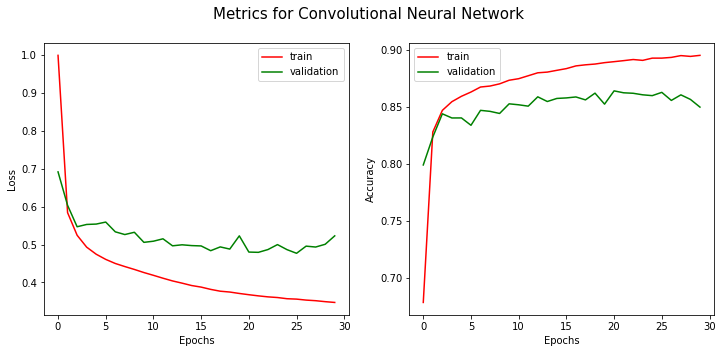

In [35]:
fig, (cnn_loss_ax, cnn_acc_ax) = plt.subplots(1, 2, figsize=[12, 5])
cnn_loss_ax.plot(cnn_train_loss, label="train", color="red")
cnn_loss_ax.plot(cnn_val_loss, label="validation", color="green")
cnn_loss_ax.set(xlabel="Epochs", ylabel="Loss")
cnn_loss_ax.legend()

cnn_acc_ax.plot(cnn_train_acc, label="train", color="red")
cnn_acc_ax.plot(cnn_val_acc, label="validation", color="green")
cnn_acc_ax.set(xlabel="Epochs", ylabel="Accuracy")
cnn_acc_ax.legend()

fig.suptitle("Metrics for Convolutional Neural Network", fontsize=15);

In [36]:
cnn_loss, cnn_acc = conv_model.evaluate(test_images_transpose, encoded_test_labels, verbose=0)
print(f"The CNN had a loss {cnn_loss:.4f} with {cnn_acc:%} accuracy")

The CNN had a loss 0.5228 with 84.964657% accuracy


## Get model predictions
* Load the best weights for the MLP and CNN models saved during the training run.
* Randomly select 5 images and corresponding labels from the test set and display the images with their labels.
* Alongside the image and label, show each model’s predictive distribution as a bar chart and the final model prediction given by the label with maximum probability.

In [37]:
mlp_best_weights = tf.train.latest_checkpoint(mlp_dir_path)
cnn_best_weights = tf.train.latest_checkpoint(cnn_dir_path)


new_mlp = create_mlp()
new_conv = create_convolutional_model()

new_mlp.load_weights(mlp_best_weights)
new_conv.load_weights(cnn_best_weights)

In [79]:
random_idx = np.random.choice(test_images_transpose.shape[0], 5)
random_test_images = test_images_transpose[random_idx]
random_test_labels = test_labels[random_idx]

mlp_predicts = new_mlp.predict(random_test_images)
cnn_predicts = new_conv.predict(random_test_images)

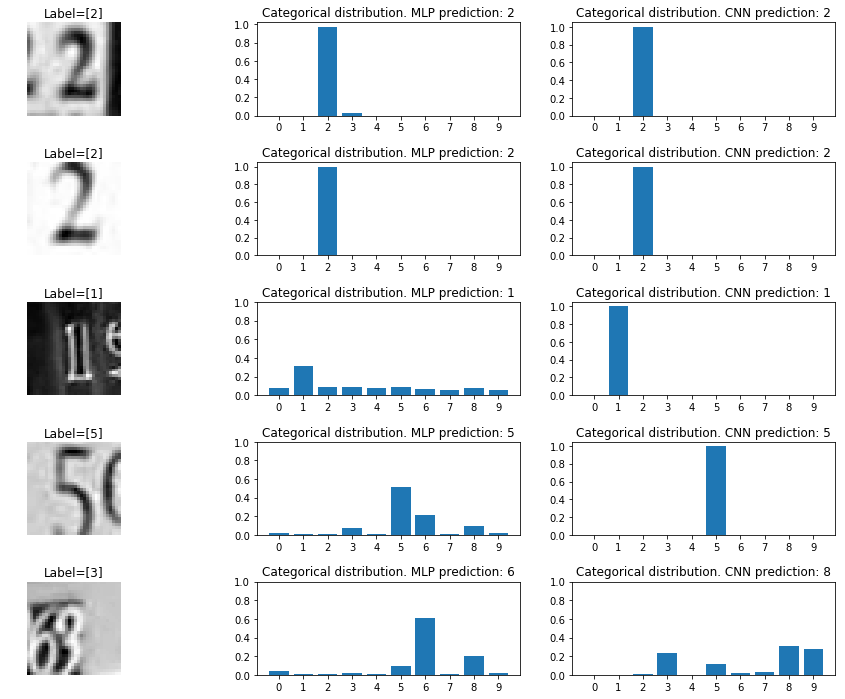

In [80]:
fig, axs = plt.subplots(5, 3, figsize=[16, 12])
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i in range(len(random_idx)):
    axs[i, 0].imshow(random_test_images[i].reshape(32, 32), cmap="gray")
    axs[i, 0].set_title("Label={}".format(random_test_labels[i]))
    axs[i, 0].axis('off')
    axs[i, 1].bar(np.arange(len(mlp_predicts[i])), mlp_predicts[i])
    axs[i, 1].set_title(f"Categorical distribution. MLP prediction: {np.argmax(mlp_predicts[i])}")
    axs[i, 1].set_xticks(np.arange(10))
    axs[i, 1].set_yticks(np.arange(0.0, 1.2, 0.2))
    axs[i, 2].bar(np.arange(len(cnn_predicts[i])), cnn_predicts[i])
    axs[i, 2].set_xticks(np.arange(10))
    axs[i, 2].set_yticks(np.arange(0.0, 1.2, 0.2))
    axs[i, 2].set_title(f"Categorical distribution. CNN prediction: {np.argmax(cnn_predicts[i])}")